# MVP - Machine Learning & Analytics PUC RJ

**Nome:** Luis Carlos Firmino Pinheiro  
**Matrícula:** 4052026000838  
**Data:** 13/06/2026  
**Dataset:** [SINISTROS DE TRÂNSITO - PRF](https://dados.gov.br/dados/conjuntos-dados/sinistros-de-transito-agrupados-por-ocorrencia)  
**Tipo de problema:** Classificação  

# 1. Definição do problema
## 1.1 Descrição do problema

No ano de 2025 a PRF registrou 72.529 sinistros de trânsito, com 83.550 feridos e 6.043 fatalidades.

Existem diversos estudos analisando informações históricas sobre ocorrências, quando foram, como ocorreram, o que as causaram. Mas e se utilizarmos esses mesmos dados em tempo real, durante a informação de uma ocorrência, seja por ligação ou por alertas gerados por aplicativos de navegação,  poderíamos com essas informações, saber se uma ocorrência será com ou sem feridos, ou até mesmo vitimas fatais, mesmo antes de se chegar ao local?

Será que um modelo preditivo tem um desempenho melhor que apenas uma analise exploratória dos locais mais frequentes, analise de risco e afins?  

Machine Learning nos permite analisar multiplas interações e fatores ao mesmo tempo, e é dai que esperamos que o desempenho seja melhor do que uma analise exploratória. 

A ideia é que o modelo seja utilizado na linha de frente de centrais de atendimento a ocorrência para auxiliar na tomada de decisões, otimizando o tipo de resposta, equipes e recursos utilizados, com um foco especial em evitar falsos negativos de ocorrências graves, já que estamos lidando com vidas.

A base de dados que iremos utilizar é [SINISTROS DE TRÂNSITO - PRF](https://dados.gov.br/dados/conjuntos-dados/sinistros-de-transito-agrupados-por-ocorrencia) da PRF, que conta com dados de acidentes em rodovias brasileiras, categorizados por gravidade, causa, tipos, dentre outras informações relevantes ao acidente.

## 1.2 Objetivo do MVP

**Objetivo deste trabalho:**  
> O Objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever a gravidade de um acidente a partir de informações disponíveis no momento em que ocorreu, comparando uma abordagem baseline com modelos candidatos e discutindo suas limitações.


## 1.3 Tipo de problema

**Tipo escolhido:** Classificação Multiclasse  
**Justificativa:** Estamos prevendo o rótulo de gravidade associado à ocorrência no campo: `classificacao_acidente` 
1. Sem Vítimas
1. Com Vítimas Feridas
1. Com Vítimas Fatais

## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. Features de contexto como horário, localização, tipo de via, e outros carregam um sinal preditivo suficiente para superar o baseline, mesmo sem a descrição do acidente. 
1. 
1. O modelo comete menos erros de falso negativo do que o baseline.
1. 

**Critérios de sucesso:**
- Métrica principal: F1-score Macro (Multiclasse).
- Métrica secundária: Avaliar Recall da classe `Com Vítimas Fatais`
- Resultado mínimo esperado: #TODO
- Restrição prática: #TODO


# 2. Ambiente, bibliotecas e reprodutibilidade

In [1]:
import random
import sys
import calendar


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, RobustScaler, StandardScaler, MinMaxScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

from sklearn.metrics import f1_score, ConfusionMatrixDisplay, accuracy_score, recall_score

import holidays


SEED = 2026
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)

Python: 3.14.2
Seed: 2026


In [2]:
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

## 2.1 Dependências adicionais

In [3]:
# !pip install -q lightgbm catboost xgboost

## 2.2 Funções auxiliares

In [61]:
def adicionar_feriados(df, coluna_data, coluna_uf, pais="BR"):
    """
    Adiciona flags (1 ou 0) para feriados, vespera e pos feriado
    considerando feriados estaduais com base em uma coluna de UF do dataframe
    """

    df[coluna_data] = pd.to_datetime(df[coluna_data])
    datas_limpas = df[coluna_data].dt.normalize()

    df["feriado"] = 0
    df["vespera_feriado"] = 0
    df["pos_feriado"] = 0

    for uf, grupo in df.groupby(coluna_uf):
        if pd.isna(uf):
            continue

        anos_presentes = grupo[coluna_data].dt.year.dropna().unique().tolist()

        try:
            feriados_obj = holidays.country_holidays(
                pais, subdiv=str(uf).upper(), years=anos_presentes
            )
        except (KeyError, ValueError):
            feriados_obj = holidays.country_holidays(pais, years=anos_presentes)

        datas_feriados = pd.to_datetime(list(feriados_obj.keys()))

        indices_grupo = grupo.index
        datas_grupo = datas_limpas.loc[indices_grupo]

        df.loc[indices_grupo, "feriado"] = datas_grupo.isin(datas_feriados).astype(
            "int8"
        )
        df.loc[indices_grupo, "vespera_feriado"] = (
            (datas_grupo + pd.Timedelta(days=1)).isin(datas_feriados).astype("int8")
        )
        df.loc[indices_grupo, "pos_feriado"] = (
            (datas_grupo - pd.Timedelta(days=1)).isin(datas_feriados).astype("int8")
        )

    return df


def reclassificar_ocorrencia(row):
    """
    Recupera a classificacao da ocorrencia baseando-se em outras colunas de dados
    """
    if row["mortos"] > 0:
        return "Com vítimas fatais"
    elif row["feridos"] > 0:
        return "Com vítimas feridas"
    else:
        return "Sem vítimas"


def sen_cos_variavel(serie: pd.Series, periodo=int) -> tuple[pd.Series, pd.Series]:
    """
    Codifica uma variavel em seu seno e coseno, util para informacao cilica como horario
    """
    sin = np.sin(2 * np.pi * serie / periodo)
    cos = np.cos(2 * np.pi * serie / periodo)

    return sin, cos


def plotar_grafico(
    data: pd.DataFrame | pd.Series,
    kind: str,
    title: str,
    x_label: str,
    y_label: str,
    figsize=(14, 6),
):
    fig, ax = plt.subplots(figsize=figsize)

    data.plot(kind=kind, ax=ax)

    ax.set_title(title, loc="left")
    ax.set_xlabel(x_label, loc="left")
    ax.set_ylabel(y_label, loc="top")

    if kind == "bar":
        ax.get_yaxis().set_visible(False)
        ax.grid(visible=False)
        plt.xticks(rotation=0)

    elif kind == "barh":
        ax.get_xaxis().set_visible(False)

    if kind in ["bar", "barh"]:
        for container in ax.containers:
            ax.bar_label(container=container)

    plt.show()


def barras_empilhadas(
    data: pd.DataFrame | pd.Series,
    kind: str,
    title: str,
    x_label: str,
    y_label: str,
    category: str = "Categorias",
    figsize=(14, 6),
):
    fig, ax = plt.subplots(figsize=figsize)

    data.plot(kind=kind, stacked=True, ax=ax, width=0.7)

    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    if kind == "bar":
        ax.tick_params(axis="x", rotation=0)
        ax.get_yaxis().set_visible(False)

    ax.grid(visible=False)

    for container in ax.containers:
        ax.bar_label(
            container=container, fmt="%.1f%%", label_type="center",
        )

    plt.legend(title=category, bbox_to_anchor=(1.01, 1), loc="upper left")

    plt.tight_layout()

    plt.show()

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

Descreva a base escolhida.

**O que incluir:**
- nome do dataset;
- link da fonte;
- por que esse dataset foi escolhido;
- quais restrições ou condições foram consideradas;
- se há questões de ética, privacidade, confidencialidade ou licença.

> **Comentário:** o dataset deve ser diferente dos utilizados nas aulas e deve ser carregado diretamente no notebook, sem upload manual e sem depender de arquivos locais.

## 3.2 Carga dos dados


In [5]:
dataset_path = "./data/dados_prf.parquet"

df = pd.read_parquet(dataset_path)

df.head()

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,ano,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,"1,000,329.00",29/10/2010,Sexta,14:20:00,RS,285.00,397.3,SANTA BARBARA DO SUL,Velocidade incompatível,Saída de Pista,Sem Vítimas,Pleno dia,Crescente,Chuva,Simples,Curva,Rural,"2,010.00",5,0,0,0,5,0,0,1,NaN,NaN,NaN,NaN,NaN
1,"1,000,837.00",14/12/2010,Terça,22:00:00,SP,116.00,406.5,MIRACATU,Outras,Colisão com objeto fixo,Sem Vítimas,Plena noite,Crescente,Chuva,Dupla,Reta,Rural,"2,010.00",1,0,0,0,1,0,0,1,NaN,NaN,NaN,NaN,NaN
2,"1,002,150.00",07/03/2010,Domingo,16:00:00,BA,407.00,220.8,CAPIM GROSSO,Velocidade incompatível,Capotamento,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Simples,Reta,Rural,"2,010.00",3,0,0,2,1,0,2,1,NaN,NaN,NaN,NaN,NaN
3,"1,003,283.00",26/10/2010,Terça,14:20:00,BA,116.00,567,NOVA ITARANA,Outras,Colisão com objeto fixo,Sem Vítimas,Pleno dia,Crescente,Ceu Claro,Múltipla,Reta,Rural,"2,010.00",1,0,0,0,1,0,0,1,NaN,NaN,NaN,NaN,NaN
4,"1,004,212.00",15/09/2010,Quarta,12:30:00,SE,101.00,107,SAO CRISTOVAO,Falta de atenção,Colisão com objeto fixo,Com Vítimas Feridas,Pleno dia,Decrescente,Ceu Claro,Simples,Reta,Rural,"2,010.00",2,0,2,0,0,0,2,1,NaN,NaN,NaN,NaN,NaN


## 3.3 Visão geral do dataset e tratamento de dados

### Linhas e Colunas

In [6]:
print(f"Linhas: {df.shape[0]}\nColunas: {df.shape[1]}")

Linhas: 2218342
Colunas: 31


### Tipos dos dados

In [7]:
display(df.dtypes.to_frame("Tipo"))
print(f"Uso de memória: {df.memory_usage().sum() / 1e+6:.1f} mb")

,Tipo
id,float64
data_inversa,str
dia_semana,str
horario,str
uf,str
br,float64
km,str
municipio,str
causa_acidente,str
tipo_acidente,str


Uso de memória: 903.6 mb


Temos oportunidades de reduzir o uso de memoria otimizando os tipos desses dados.  
Vamos normalizar os textos e tratar como categorias, além de reduzir a quantidade de bits de algumas variaveis numéricas.

In [8]:
df["id"] = df["id"].astype(int)
df["data_inversa"] = pd.to_datetime(df["data_inversa"], format="mixed")
df["dia_semana"] = df["dia_semana"].str.lower().str.strip().str.removesuffix("-feira").astype("category")
df["horario"] = pd.to_timedelta(df["horario"])
df["uf"] = df["uf"].str.upper().str.strip().astype("category")
df["br"] = df["br"].astype("Int16")
df["km"] = df["km"].str.replace(",", ".").astype("float16")
df["municipio"] = df["municipio"].str.upper().str.strip().astype("category")
df["causa_acidente"] = df["causa_acidente"].str.strip().str.capitalize().astype("category")
df["tipo_acidente"] = df["tipo_acidente"].str.strip().str.capitalize().astype("category")
df["classificacao_acidente"] = df["classificacao_acidente"].str.strip().str.capitalize().astype("category")
df["fase_dia"] = df["fase_dia"].str.strip().str.capitalize().astype("category")
df["sentido_via"] = df["sentido_via"].str.strip().str.capitalize().astype("category")
df["condicao_metereologica"] = df["condicao_metereologica"].str.strip().str.capitalize().astype("category")
df["tipo_pista"] = df["tipo_pista"].str.strip().str.capitalize().astype("category")
df["tracado_via"] = df["tracado_via"].str.strip().str.capitalize().astype("category")
df["uso_solo"] = df["uso_solo"].str.strip().str.capitalize().astype("category")
df["ano"] = df["ano"].astype("Int16")
df["pessoas"] = df["pessoas"].astype("int8")
df["mortos"] = df["mortos"].astype("int8")
df["feridos_leves"] = df["feridos_leves"].astype("int8") 
df["feridos_graves"] = df["feridos_graves"].astype("int8")
df["ilesos"] = df["ilesos"].astype("int8")
df["ignorados"] = df["ignorados"].astype("int8")
df["feridos"] = df["feridos"].astype("int8")
df["veiculos"] = df["veiculos"].astype("int8")
df["latitude"] = df["latitude"].str.replace(",", ".").astype("float32")
df["longitude"] = df["longitude"].str.replace(",", ".").astype("float32")
df["regional"] = df["regional"].str.strip().str.upper().astype("category")
df["delegacia"] = df["delegacia"].str.strip().str.upper().astype("category")
df["uop"] = df["uop"].str.strip().str.upper().astype("category")


### Novos tipos do Dataset

In [9]:
display(df.dtypes.to_frame("Tipo"))
print(f"Uso de memória: {df.memory_usage().sum() / 1e+6:.1f} mb")

,Tipo
id,int64
data_inversa,datetime64[us]
dia_semana,category
horario,timedelta64[us]
uf,category
br,Int16
km,float16
municipio,category
causa_acidente,category
tipo_acidente,category


Uso de memória: 148.8 mb


### Valores ausentes por coluna

In [10]:
print("Valores ausentes por coluna")
df.isna().sum().to_frame("Ausentes")

Valores ausentes por coluna


,Ausentes
id,0
data_inversa,0
dia_semana,0
horario,0
uf,12
br,12
km,12
municipio,0
causa_acidente,2
tipo_acidente,41


**Temos valores ausentes nas colunas:**

- `uf`
- `br`
- `km`

Essas colunas são indicativos de onde ocorreu o acidente, sem isso não temos para onde enviar o socorro. Como são apenas 12 exemplos em um dataset de 2218342, não perderiamos muita informação ao remover essas linhas.

- `causa_acidente`  É determinada após investigação do fato, então não será parte do modelo

- `tipo_acidente`  Pode até ser conhecido no momento que a ocorrência é informada. Vale analisar posteriormente se será mantida ou não, dependendo do tipo de informação.

- **`classificacao_acidente` É o nosso alvo de predição, linhas sem esse alvo não tem valor para nós. Mas ainda vale a pena verificar se os casos sem essa classificacao foram apenas erro de preenchimento e se podemos derivar essa informação a partir do numero de vitimas leves e graves.**

- `fase_dia`
É redundante pois `horario` já contém essa informação.

- `condicao_metereologica` Pode ser um fator importante, mas novamente a quantidade de registros em branco é mínima. Caso exista uma condicao "Nao Informada" ou "Outros" acredito que da para agrupar.

- `tipo_pista`
- `tracado_via`
- `uso_solo`

Essas 3 tem poucos registros sem essa informação, mas ainda cabe avaliacao se são importantes para o modelo ou não.

- `ano` pode ser determinado pela coluna `data_inversa`

- `latitude` 
- `longitude`

Essas duas tem um volume expressivo de nulos, podemos verificar se foi uma informação que começou a ser preenchida a partir de um determinado ano, o que indicaria que houveram mudanças no processo de preenchimento. 


- `regional`
- `delegacia`
- `uop`

Essas tambem tem um numero grande de nulos, semelhante ao de `latitude` e `longitude`, o que reforça que houve mudanças de processo. Mas no caso dessas me parecem mais colunas processuais do registro de ocorrência, que não teriam utilidade no modelo.




### Duplicatas

In [11]:
print("Duplicatas:", df.duplicated().sum())

Duplicatas: 0


### Adicao de informacao ao dataset

Uma das informaçoes que acredito ser útil é a de feriados. Os feriados aumentam a demanda em rodovias então podem ser um forte influenciador.
Alem de feriados, vamos adicionar tambem vesperas e pos feriados como flags.

In [12]:
df = adicionar_feriados(df, "data_inversa", "uf")

### Inspecao da variavel alvo

In [13]:
print("Valores da variavel alvo")
df["classificacao_acidente"].value_counts(dropna=False).to_frame("n").reset_index()

Valores da variavel alvo


,classificacao_acidente,n
0,Com vítimas feridas,1061611
1,Sem vítimas,1037136
2,Com vítimas fatais,107898
3,Ignorado,11660
4,NaN,37


Vamos inspecionar alguns desses NaN

In [14]:
df[df["classificacao_acidente"].isna()].sample(10, random_state=SEED)

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,ano,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop,feriado,vespera_feriado,pos_feriado
1746126,14,2014-11-09,domingo,0 days 22:50:00,SC,101,220.88,PALHOCA,Falta de atenção,Colisão com objeto fixo,NaN,Plena noite,Decrescente,Ceu claro,Dupla,Reta,Urbano,2014,1,0,1,0,0,0,1,1,NaN,NaN,NaN,NaN,NaN,0,0,0
766680,600126,2009-10-23,sexta,0 days 06:15:00,SP,116,504.00,CAJATI,Outras,Saída de pista,NaN,Amanhecer,Crescente,Chuva,Simples,Reta,Rural,2009,1,0,0,0,0,0,0,1,NaN,NaN,NaN,NaN,NaN,0,0,0
1521569,405151,2022-01-01,sábado,0 days 01:35:00,PI,316,415.00,MARCOLANDIA,Ingestão de álcool pelo condutor,Colisão traseira,NaN,Plena noite,Decrescente,Nublado,Simples,Reta,Sim,<NA>,3,0,1,0,1,1,1,3,-7.43,-40.68,SPRF-PI,DEL04-PI,UOP03-DEL04-PI,1,0,0
1987855,496590,2023-01-01,domingo,0 days 01:40:00,MT,163,"1,112.00",GUARANTA DO NORTE,Reação tardia ou ineficiente do condutor,Tombamento,NaN,Plena noite,Crescente,Ignorado,Simples,Curva;declive,Não,<NA>,2,0,0,1,0,2,1,3,-9.70,-54.88,SPRF-MT,DEL06-MT,UOP03-DEL06-MT,1,0,0
708317,539237,2009-11-06,quinta,0 days 18:45:00,MG,381,492.00,BETIM,Outras,Saída de pista,NaN,Plena noite,Crescente,Ceu claro,Dupla,Reta,Urbano,2009,1,0,0,0,0,0,0,1,NaN,NaN,NaN,NaN,NaN,0,0,0
563249,231770,2007-05-23,quarta,0 days 15:30:00,ES,262,75.69,DOMINGOS MARTINS,Falta de atenção,Saída de pista,NaN,Pleno dia,Crescente,Sol,Simples,Curva,Rural,2007,1,0,0,0,0,0,0,1,NaN,NaN,NaN,NaN,NaN,0,0,0
1746128,16,2014-11-22,sábado,0 days 07:50:00,PR,277,95.00,CURITIBA,Defeito mecânico em veículo,Saída de pista,NaN,Pleno dia,Decrescente,Chuva,Dupla,Curva,Rural,2014,1,0,1,0,0,0,1,1,NaN,NaN,NaN,NaN,NaN,0,0,0
1746132,8,2014-11-22,sábado,0 days 09:35:00,PR,376,335.50,ORTIGUEIRA,Defeito mecânico em veículo,Saída de pista,NaN,Pleno dia,Crescente,Chuva,Simples,Curva,Rural,2014,3,0,0,0,3,0,0,3,NaN,NaN,NaN,NaN,NaN,0,0,0
1746124,12,2014-11-22,sábado,0 days 08:30:00,SP,116,212.00,GUARULHOS,Outras,Colisão com objeto fixo,NaN,Pleno dia,Crescente,Sol,Múltipla,Reta,Urbano,2014,1,0,0,0,0,1,0,1,NaN,NaN,NaN,NaN,NaN,0,0,0
954477,83362881,2015-06-02,terça,0 days 16:20:00,MG,50,145.00,UBERABA,Velocidade incompatível,Saída de pista,NaN,Pleno dia,Crescente,Chuva,Dupla,Reta,Rural,2015,1,0,0,0,0,0,0,1,NaN,NaN,NaN,NaN,NaN,0,0,0


Há registros onde mesmo com o rótulo ausente, ainda temos informações nas colunas `mortos` e `feridos`. Podemos recuperar esses rótulos dessa linha aplicando regras com base nesses valores. Podemos fazer isso tanto para os casos *NaN* quanto para os *Ignorado*.

Meu unico receio é em classificar os erroneamente *Ignorado* como *Sem vítima* quando a informação não for confiavel.

Por isso vamos inspecionar esses casos primeiro.

Os NaN são poucos então vamos mostra-los diretamente.

In [15]:
df[df["classificacao_acidente"].isna()][
    ["pessoas","mortos", "feridos_leves", "feridos_graves", "ilesos", "ignorados", "feridos"]
]

,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos
219707,1,0,0,0,1,0,0
271134,1,0,0,0,0,0,0
314888,1,0,0,0,0,0,0
327586,1,0,0,0,0,0,0
446658,1,0,0,0,0,0,0
516838,9,0,4,0,5,0,4
516839,9,0,4,0,5,0,4
558106,1,0,0,0,0,0,0
563249,1,0,0,0,0,0,0
603231,1,0,0,0,0,0,0


In [16]:
df[df["classificacao_acidente"].isna()][
    ["pessoas","mortos", "feridos_leves", "feridos_graves", "ilesos", "ignorados", "feridos"]
].sum()

pessoas           96
mortos             3
feridos_leves     20
feridos_graves     6
ilesos            42
ignorados         20
feridos           26
dtype: int64

> Realmente temos informações de feridos, então faz sentido utilizar a regra nesses casos.

Agora para os Ignorados

In [17]:
df[df["classificacao_acidente"] == "Ignorado"].sample(n=15, random_state=SEED) 

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,ano,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop,feriado,vespera_feriado,pos_feriado
658944,487531,2009-08-02,domingo,0 days 13:00:00,AC,317,152.00,CAPIXABA,Velocidade incompatível,Saída de pista,Ignorado,Pleno dia,Decrescente,Nublado,Simples,Curva,Rural,2009,1,0,0,0,0,1,0,1,NaN,NaN,NaN,NaN,NaN,0,0,0
260746,874879,2011-03-20,domingo,0 days 01:00:00,PR,476,118.00,COLOMBO,Velocidade incompatível,Colisão com objeto fixo,Ignorado,Plena noite,Crescente,Nublado,Dupla,Reta,Urbano,2011,1,0,0,0,0,1,0,1,NaN,NaN,NaN,NaN,NaN,0,0,0
960986,83369662,2015-06-14,domingo,0 days 04:40:00,SP,116,225.00,GUARULHOS,Outras,Tombamento,Ignorado,Plena noite,Decrescente,Ceu claro,Múltipla,Reta,Urbano,2015,2,0,0,0,0,2,0,1,NaN,NaN,NaN,NaN,NaN,0,0,0
1834599,83216856,2014-07-04,sexta,0 days 23:40:00,MG,50,81.00,UBERLANDIA,Outras,Saída de pista,Ignorado,Plena noite,Decrescente,Ceu claro,Dupla,Curva,Rural,2014,1,0,0,0,0,1,0,1,NaN,NaN,NaN,NaN,NaN,0,0,0
266934,881378,2011-02-04,sábado,0 days 18:30:00,RS,386,32.91,FREDERICO WESTPHALEN,Velocidade incompatível,Capotamento,Ignorado,Anoitecer,Decrescente,Nublado,Simples,Reta,Urbano,2011,1,0,0,0,0,1,0,1,NaN,NaN,NaN,NaN,NaN,0,0,0
1778844,83158841,2014-03-08,sábado,0 days 01:50:00,SC,280,7.50,SAO FRANCISCO DO SUL,Falta de atenção,Colisão com objeto fixo,Ignorado,Plena noite,Decrescente,Chuva,Simples,Reta,Urbano,2014,1,0,0,0,0,1,0,1,NaN,NaN,NaN,NaN,NaN,0,0,0
1012567,83423530,2015-12-25,sexta,0 days 03:00:00,ES,101,402.00,ITAPEMIRIM,Outras,Incêndio,Ignorado,Pleno dia,Crescente,Ceu claro,Simples,Reta,Rural,2015,1,0,0,0,0,1,0,1,NaN,NaN,NaN,NaN,NaN,1,0,0
967501,83376486,2015-07-12,domingo,0 days 22:20:00,PR,277,433.00,VIRMOND,Outras,Capotamento,Ignorado,Plena noite,Crescente,Nublado,Simples,Reta,Urbano,2015,1,0,0,0,0,1,0,1,NaN,NaN,NaN,NaN,NaN,0,0,0
297469,915368,2011-05-29,domingo,0 days 11:20:00,BA,116,436.00,FEIRA DE SANTANA,Outras,Tombamento,Ignorado,Pleno dia,Decrescente,Ceu claro,Simples,Reta,Rural,2011,1,0,0,0,0,1,0,1,NaN,NaN,NaN,NaN,NaN,0,0,0
244604,857340,2011-02-19,sábado,0 days 06:50:00,PE,232,78.31,GRAVATA,Outras,Colisão com objeto fixo,Ignorado,Pleno dia,Crescente,Sol,Simples,Reta,Urbano,2011,1,0,0,0,0,1,0,1,NaN,NaN,NaN,NaN,NaN,0,0,0


In [18]:
df[df["classificacao_acidente"] == "Ignorado"][
    [
        "pessoas",
        "mortos",
        "feridos_leves",
        "feridos_graves",
        "ilesos",
        "ignorados",
        "feridos",
    ]
].sum()

pessoas           13421
mortos                0
feridos_leves         0
feridos_graves        0
ilesos                0
ignorados         13420
feridos               0
dtype: int64

>Os dados com rotulo Ignorado não tem dados sobre feridos ou mortos, o que ajudaria na reclassificação.

OS tipos de acidentes com rotulo Ignorado

In [19]:
df[df["classificacao_acidente"] == "Ignorado"]["tipo_acidente"].value_counts()

tipo_acidente
Saída de pista                                4796
Colisão com objeto fixo                       2310
Capotamento                                   2047
Tombamento                                     507
Queda de motocicleta / bicicleta / veículo     440
Colisão traseira                               370
Incêndio                                       339
Atropelamento de animal                        189
Colisão lateral                                170
Colisão transversal                            113
Atropelamento de pessoa                         95
Colisão frontal                                 90
Danos eventuais                                 76
Colisão com objeto móvel                        50
Derramamento de carga                           38
Colisão com bicicleta                           30
Atropelamento de pedestre                        0
Colisão com objeto                               0
Colisão com objeto em movimento                  0
Colisão com objet

> Temos alguns acidentes com potencial grave nesse meio como Capotamento e Atropelamento de pessoa

Em que ano estão concentrados os Ignorados?

In [20]:
df[df["classificacao_acidente"] == "Ignorado"].groupby(df["data_inversa"].dt.year)["id"].count()

data_inversa
2007     433
2008     589
2009     730
2010     992
2011    1161
2012    1374
2013    1537
2014    1661
2015    1527
2016    1656
Name: id, dtype: int64

> Os dados com rotulo de Ignorado so vão até o ano de 2016. Agora recordando daqueles dados que suspeitava ser por mudança de processo como latitude e longitude, vamos ver como eles se comportam também.

In [21]:
df[df["latitude"].isna()].groupby(df["data_inversa"].dt.year).id.count()

data_inversa
2007    127675
2008    141043
2009    158646
2010    183469
2011    192326
2012    184568
2013    186748
2014    169201
2015    122161
2016     96363
Name: id, dtype: int64

> Como suspeitava, eles tambem só começaram a ser preenchidos após 2016

### Ponderação sobre utilização de dados anteriores a 201&

Os Ignorados não apresentam nenhum dado de feridos ou mortos, ou seja realmente não temos certeza do que ocorreu.

Temos alguns exemplos de tipos de acidente que aparentam ser graves como Atropelamento de pessoa, Capotamento, Colisão transversal, que teriam grande probabilidade de deixar feridos. Realmente não houve feridos ou não foi registrado?

Isso aliado ao fato de que tivemos a inclusão de novas variaveis em 2017, me leva a crer que houve realmente uma mudança de processo no preenchimento das informações.

Diante disso acredito que o melhor caminho seja restringir esse estudo para 2017 em diante. E por alguns motivos: a mudança no padrão de preenchimento, e durante um período tão grande de quase 20 anos, tivemos diversas mudanças nas normas de segurança, obrigatoriedade de airbags em novos veículos e atualização da infraestrutura rodoviária. 

Mesmo com essa restrição, ainda teremos quase 9 anos de dados para construção do modelo.


### Reclassificacao de ocorrencias sem preenchimento

Vamos reclassificar os que podem ser reclassificados com base nas regras de feridos e mortos

In [22]:
df["classificacao_acidente"] = df["classificacao_acidente"].astype("str")
filtro_nulos = df["classificacao_acidente"].isna()
nova_classificacao = df[filtro_nulos].apply(reclassificar_ocorrencia, axis=1)
df.loc[filtro_nulos, "classificacao_acidente"] = nova_classificacao

df["classificacao_acidente"] = df["classificacao_acidente"].astype("category")

In [23]:
df["classificacao_acidente"].value_counts(dropna=False)

classificacao_acidente
Com vítimas feridas    1061624
Sem vítimas            1037157
Com vítimas fatais      107901
Ignorado                 11660
Name: count, dtype: int64

### Limitar o dataset somente a partir de 2017

Conforme discutido anteriormente, o periodo utilizado desse dataset será somente a partir de 2017

In [24]:
df = df[df["data_inversa"].dt.year > 2016]

Confirmando a nova distribuição dos dados alvo

In [25]:
df["classificacao_acidente"].value_counts(dropna=False)

classificacao_acidente
Com vítimas feridas    481231
Sem vítimas            129863
Com vítimas fatais      45048
Ignorado                    0
Name: count, dtype: int64

Como estamos usando o tipo categoria para classificao_acidente os Ignorado ainda aparecem.

In [26]:
df["classificacao_acidente"] = df["classificacao_acidente"].astype("str").astype("category")

Como a variavel `ano` apresenta valores *NaN*, vamos usar o campo `data_inversa` para extrair o ano da ocorrência

In [27]:
df["ano"] = df["data_inversa"].dt.year

### 

Uma variavel que quero tratar é a `uso_solo`, segundo informações do dicionario de dados da prf, ela informa se a ocorrência foi em trecho urbano ou rural

In [28]:
df.uso_solo.value_counts()

uso_solo
Não       372315
Sim       283827
Rural          0
Urbano         0
Name: count, dtype: int64

Agora os dados aparentam ser entre Sim e Não, entao acredito que seria melhor transformar em uma flag.

In [29]:
df["uso_solo"] = (df["uso_solo"] == "Sim").astype("int8")

In [30]:
df.uso_solo.value_counts()

uso_solo
0    372315
1    283827
Name: count, dtype: int64

### Tamanho final do dataset

In [31]:
print(f"Novo shape do dataset\n Linhas: {df.shape[0]}\n Colunas: {df.shape[1]}")

Novo shape do dataset
 Linhas: 656142
 Colunas: 34


## 3.4 Dicionário de dados (Prévia pré EDA)

Tabela com os atributos do dataset.

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| id | numérica | id da ocorrencia | não | identificador único de linha, sem informação para o modelo |
| data_inversa | data | data do acidente | *não | *será usada como ordenaçao do dataset e split temporal e não como feature|
| dia_semana | categórica  | dia da semana do acidente | sim | sim para capturar tendências durante a semana  |
| horario | timedelta | horário do acidente | sim | sim pois horário pode influenciar na visibilidade, demanda..etc |
| uf | categórica | unidade federativa onde ocorreu o acidente | sim | sim pois é essencial para localização |
| br | categórica | rodovia onde ocorreu o acidente | sim | sim pois é essencial para localização |
| km | numérica | km na rodovia onde ocorreu o acidente | sim | sim pois é essencial para localização |
| municipio | categórica | município do acidente | não | uf, br, km já nos dão informação suficiente sobre localização |
| causa_acidente | categórica | causa da ocorrência | não | determinada pós investigação, não é disponível ao modelo|
| tipo_acidente | categórica | tipo de acidente | não | é discutivel se esse tipo de informação sempre estaria disponivel ao modelo, portanto em primeiro momento será desconsiderada|
| fase_dia | categórica | fase do dia em que ocorreu | não | redundante com a coluna horario |
| sentido_via | categórica | sentido da via | *sim | *geralmente é possivel determinar o sentido da via em rodovias com mais facilidade, então vamos assumir que essa informaçao estará disponivel |
| condicao_metereologica | categórica | condição meteorologica no local do acidente | sim | intuitivamente um forte influenciador |
| tipo_pista | categórica | tipo de pista onde ocorreu o acidente | *sim | *se temos a informação de uf, br e km, é razoavel presumir que saberemos o tipo de pista, com base em algum lookup de banco de dados interno |
| tracado_via | categórica | traçado da pista | *sim | *se temos a informação de uf, br e km, é razoavel presumir que saberemos o traçado de um determindo trecho, com base em algum lookup de banco de dados interno. Provavelmente será transformado para reduzir a cardinalidade |
| uso_solo | booleano | se foi em trecho urbano ou rual | sim | informação de caracteristica da via que pode ser util, novamente assumimos que estaria disponivel com lookup em base interna |
| ano | numérica | ano da ocorrência | sim | importante para informar o modelo sobre mudanças ao longo do tempo |
| pessoas | numérica | pessoas envolvidas | não | determinada pós o fato, não seria disponivel ao modelo |
| mortos | numérica | mortos no acidente | não | determinada pós o fato, não seria disponivel ao modelo, além de ser vazamento direto de alvo |
| feridos_leves | numérica | feridos levemente no acidente | não | determinada pós o fato, não seria disponivel ao modelo, além de ser vazamento direto do alvo |
| feridos_graves | numérica | feridos gravemente no acidente | não | determinada pós o fato, não seria disponivel ao modelo, além de ser vazamento direto do alvo |
| ilesos | numérica | ilesos no acidente | não | determinada pós o fato, não seria disponivel ao modelo |
| ignorados | numérica | pessoas com estado desconhecido | não | determinada pós o fato, não seria disponivel ao modelo |
| feridos | numérica | feridos no acidente | não | determinada pós o fato, não seria disponivel ao modelo, além de ser vazamento direto do alvo |
| veiculos | numérica | veiculo envolvidos no acidente | não | discutivel se essa informação estaria disponivel ao modelo, portanto será descartada |
| latitude | numérica | latitude do acidente | indeterminado ! | ! aqui estou assumindo que latitude e longitude seria uma informação muito precisa para determinar no momento da ocorrência, pode se argumentar que poderiamos ter um lookup baseado em br + km, mas vamos explorar isso melhor adiante |
| longitude | numérica | longitude do acidente | indeterminado ! | ! aqui estou assumindo que latitude e longitude seria uma informação muito precisa para determinar no momento da ocorrência, pode se argumentar que poderiamos ter um lookup baseado em br + km, mas vamos explorar isso melhor adiante |
| regional | categórica | regional onde foi registrado o acidente | não | informação processual pós fato |
| delegacia | categórica | delegacia onde foi registrado o acidente | não | informação processual pós fato |
| uop | categórica | uop onde foi registrado o acidente | não | informação processual pós fato |
| feriado | booleano | se o dia foi feriado | sim | afeta demanda |
| vespera_feriado | booleano | se o dia foi vespera de feriado | sim | afeta demanda |
| pos_feriado | booleano | se o dia foi volta de feriado | sim | afeta demanda |
| **classificacao_acidente** | **alvo** | como o acidente foi classificado | alvo | Sem vítimas, Com vítimas feridas, Com vítimas fatais |

# 4. Análise exploratória dos dados

A análise exploratória deve ser objetiva e conectada ao problema.

**O que incluir:**
- distribuição do target;
- distribuição de variáveis importantes;
- relação entre variáveis e target;
- identificação de desbalanceamento, outliers ou padrões relevantes;
- hipóteses que surgem a partir dos dados.

> **Comentário:** siga a lógica do MVP de pré-processamento: não basta mostrar gráfico; escreva abaixo dele o que o gráfico indica e como isso influencia a modelagem.

In [32]:
plt.style.use('fivethirtyeight')

### Distribuição da variável alvo

In [33]:
print("Distribuiçao do alvo:")

dist_alvo = df["classificacao_acidente"].value_counts(dropna=False).to_frame("contagem").reset_index()

dist_alvo["percentual"] = dist_alvo["contagem"] / dist_alvo["contagem"].sum() * 100

dist_alvo

Distribuiçao do alvo:


,classificacao_acidente,contagem,percentual
0,Com vítimas feridas,481231,73.34
1,Sem vítimas,129863,19.79
2,Com vítimas fatais,45048,6.87


> Temos um problema de classificacao com classes desbalanceadas. A classe **Com vítimas feridas** aparece em quase 3/4 dos casos, seguido de **Sem vítimas** com quase 20%, e por fim **Com vítimas fatais** próximo de 7% dos casos. 

> Esse desbalanceamento pode fazer com que prever a classe majoritaria seja um atalho para o modelo, por isso F1 Macro será usado como métrica para desempenho do modelo. O F1 Macro calcula o desempenho isoladamente para cada classe, utilizando a média harmônica entre precisão e sensibilidade.

### Tendência temporal

Mesmo que `data_inversa` tenha ficado de fora como feature, afinal a gravidade de um acidente que acontece hoje não tem influência na gravidade de um acidente amanhã, acredito que é importante manter a ordenação dos dados, já que o modelo poderia ter acesso a acidentes futuros durante o treinamento. Além do que a evolução natural do tempo, com melhorias (ou pioras) de infraestruturas podem ser capturadas por essa passagem de tempo.

Como proxy de passagem de tempo, utilizaremos o ano, assim o modelo entende que 2021 < 2022 e assim por diante.

In [34]:
df = df.sort_values(by=["data_inversa", "horario"]).reset_index(drop=True)

Adicionando algumas variaveis para facilitar a exploracao.  
*Não necessáriamente se tornarão features*

In [35]:
meses = {
    1: "Jan",
    2: "Fev",
    3: "Mar",
    4: "Abr",
    5: "Mai",
    6: "Jun",
    7: "Jul",
    8: "Ago",
    9: "Set",
    10: "Out",
    11: "Nov",
    12: "Dez",
}

dias = {
    0: "Seg",
    1: "Ter",
    2: "Qua",
    3: "Qui",
    4: "Sex",
    5: "Sáb",
    6: "Dom",
}

df["mes_ano"] = df["data_inversa"].dt.to_period("M")
df["mes"] = df["data_inversa"].dt.month
df["nome_mes"] = df["data_inversa"].dt.month.map(meses)
df["dia_semana"] = df["data_inversa"].dt.day_of_week
df["nome_dia"] = df["data_inversa"].dt.day_of_week.map(dias)
df["hora"] = df["horario"].dt.components["hours"]


In [36]:
df.groupby("ano").size()

ano
2017    89567
2018    69333
2019    67558
2020    63585
2021    64567
2022    64606
2023    67766
2024    73156
2025    72529
2026    23475
dtype: int64

### Como o número de acidentes mudou ao longo do tempo?

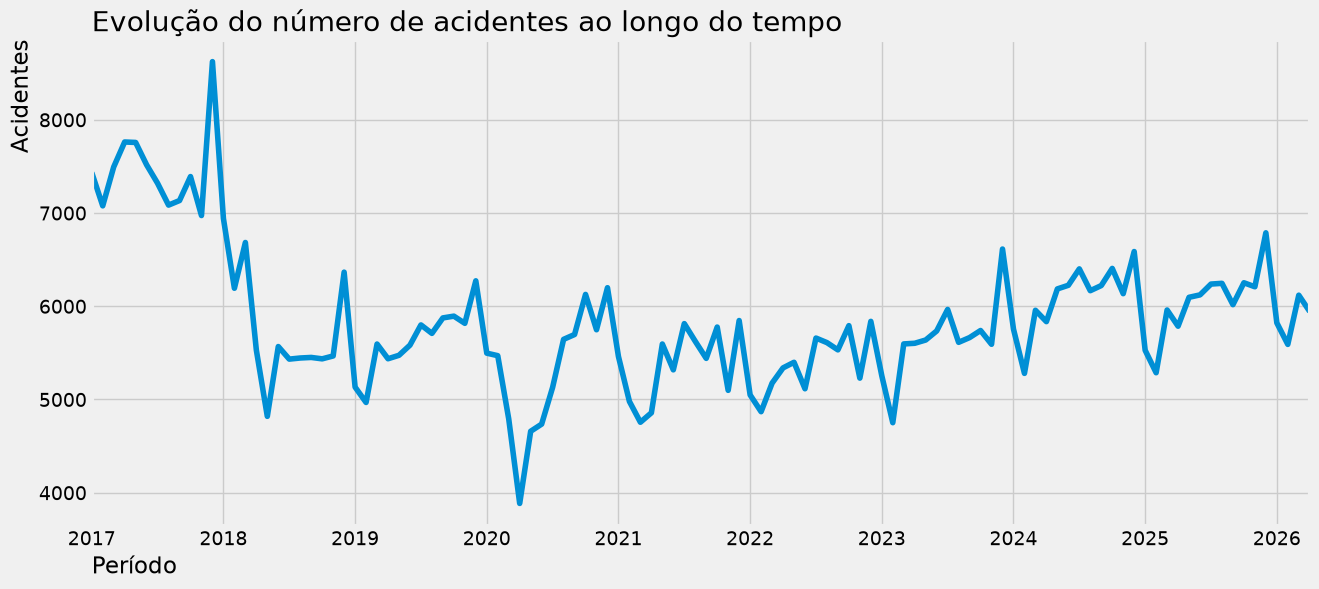

In [37]:
data = df.groupby("mes_ano").size()

plotar_grafico(
    data,
    "line",
    "Evolução do número de acidentes ao longo do tempo",
    "Período",
    "Acidentes",
)

> Olhando esse gráfico podemos notar que houve uma redução no número geral em comparação ao início do período, mas agora aparenta retomar uma tendência de alta. 
>
> Também é possível notar que existe um componente de sazonalidade, com alguns periódos de redução no início do ano, e de alta no meio do ano para o final.
>
> Uma varíavel de mês pode ser importante para o modelo.

#### Vamos inspecionar melhor a tendência anual

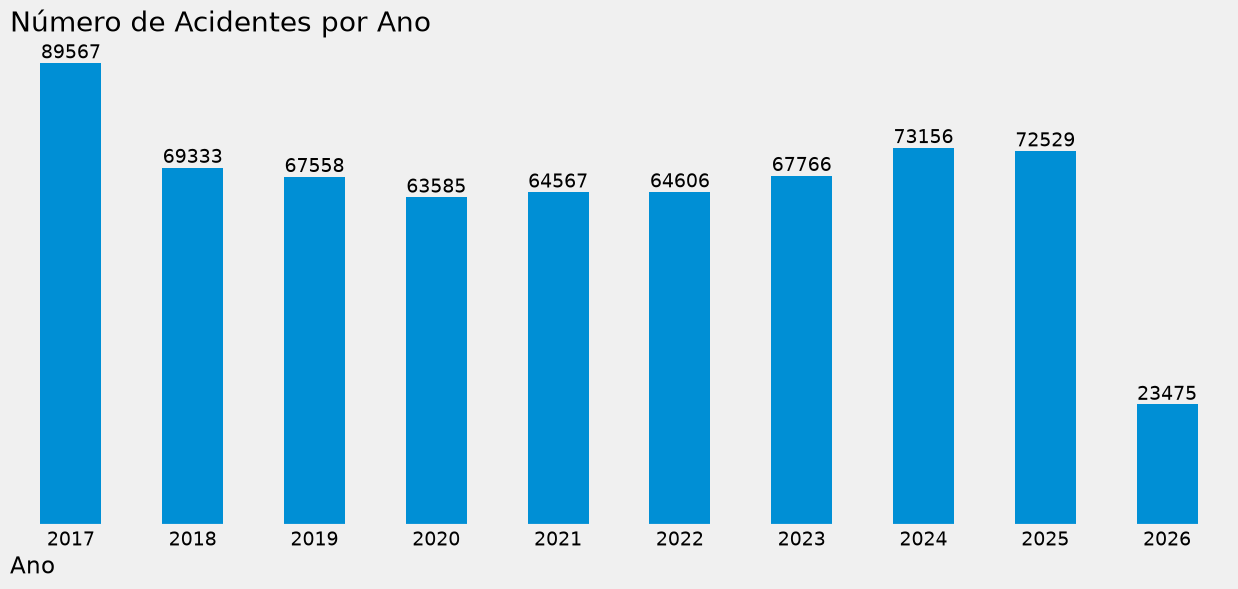

In [38]:
data = df.groupby("ano").size()

plotar_grafico(data, "bar", "Número de Acidentes por Ano", "Ano", "Acidentes")

> Claramente houve uma redução de 2017 para cá, mas temos que lembrar que 2020 a 2021 foram períodos de pandemia, oque pode ter influenciado e muito nessa redução. A tendência de alta nos anos recentes parece mais uma retomada a patamares pré pandemia.

> *Obs: 2026 ainda está incompleto*

Como o nosso objetivo é prever a gravidade, vamos ver como ela se comporta ao longo dos anos.

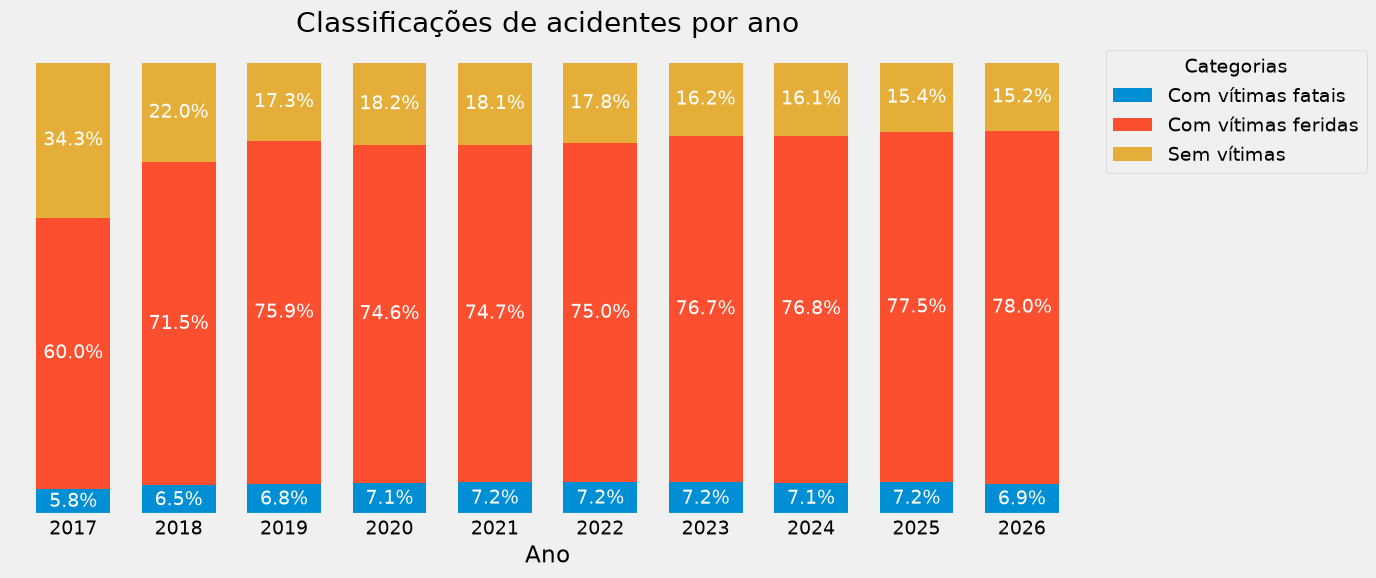

In [39]:
data = pd.crosstab(index=df["ano"], columns=df["classificacao_acidente"], normalize="index") * 100


barras_empilhadas(data, "bar", "Classificações de acidentes por ano", "Ano", "Acidentes" )


> Com exceção de 2017 e 2018 os pecentuais permanecem próximos ao longo dos anos

### Tendência Mensal

Vamos analisar a média de acidentes que ocorrem em um determinado mês

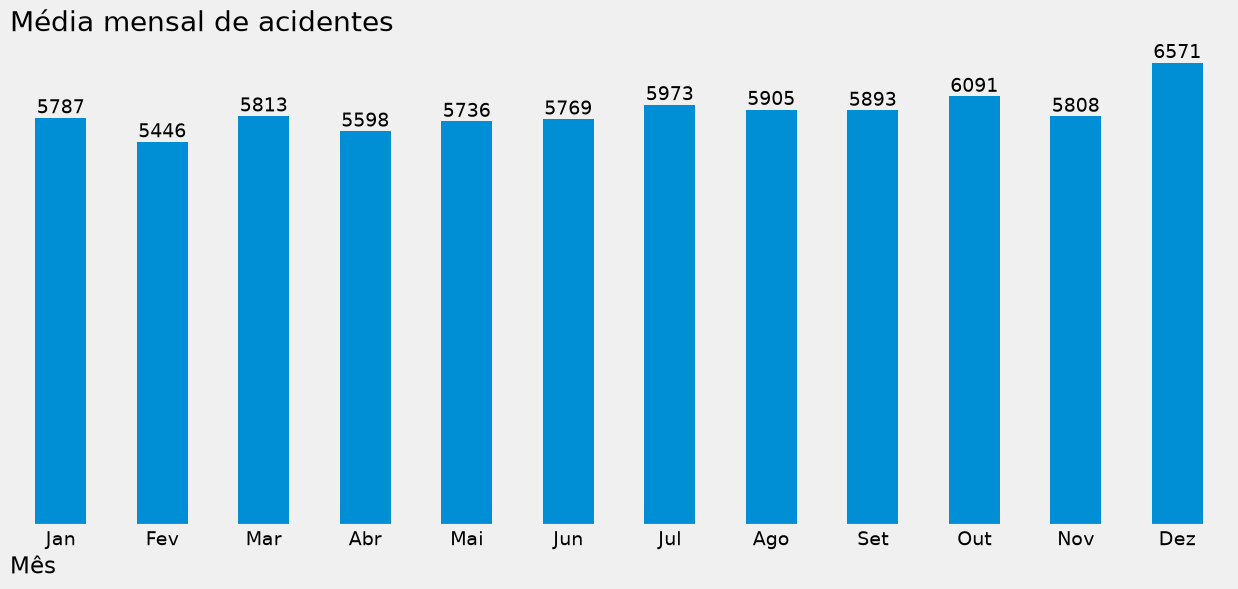

In [40]:
data = df.groupby(["ano", "mes"]).size().groupby("mes").mean().round()

data = data.rename(index=meses)

plotar_grafico(data, "bar", "Média mensal de acidentes", "Mês", y_label="Acidentes")

> Como podemos ver em média Dezembro é o mês com maior número de acidentes, o que é esperado pelas festas de fim de ano. Mas será que a classificação também muda?

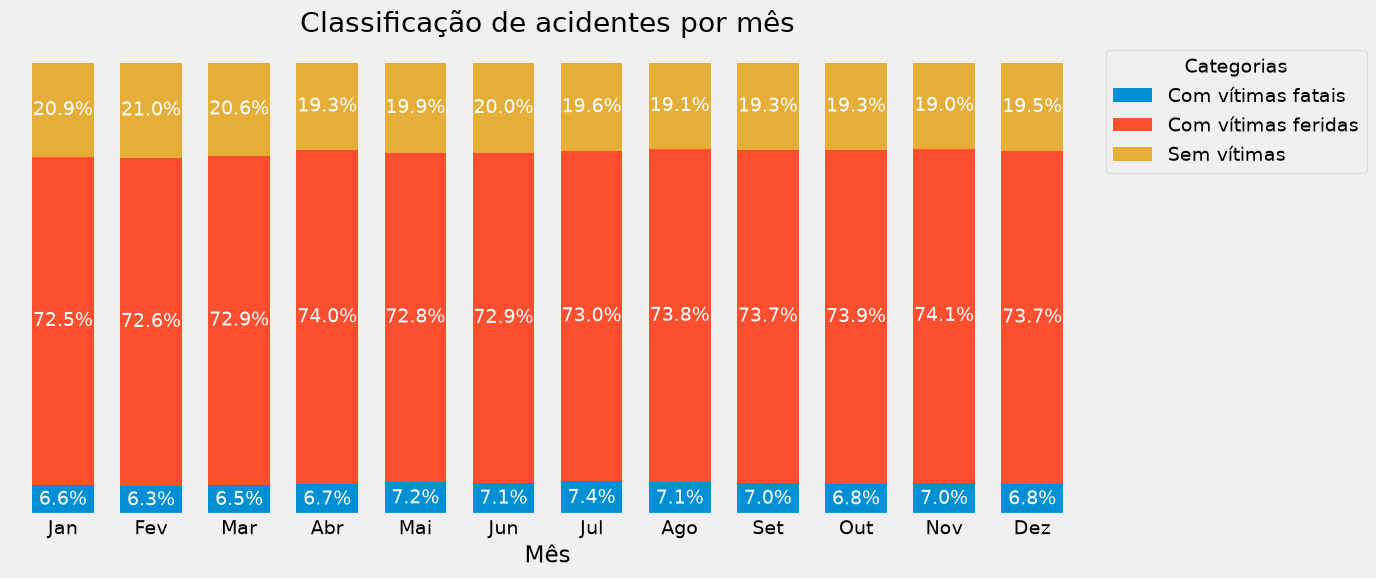

In [41]:
data = df.groupby(["ano", "mes", "classificacao_acidente"]).size().groupby(["mes", "classificacao_acidente"]).mean().unstack()

data = data.div(data.sum(axis=1), axis=0) * 100

data = data.rename(index=meses)

barras_empilhadas(data, "bar", "Classificação de acidentes por mês", "Mês", "%")

> Aparentemente a classificacao por mês é bem estável mantendo uma proporção semelhante ao longo do ano, o que varia mais mesmo é o volume

> 

### Acidentes por dia da semana

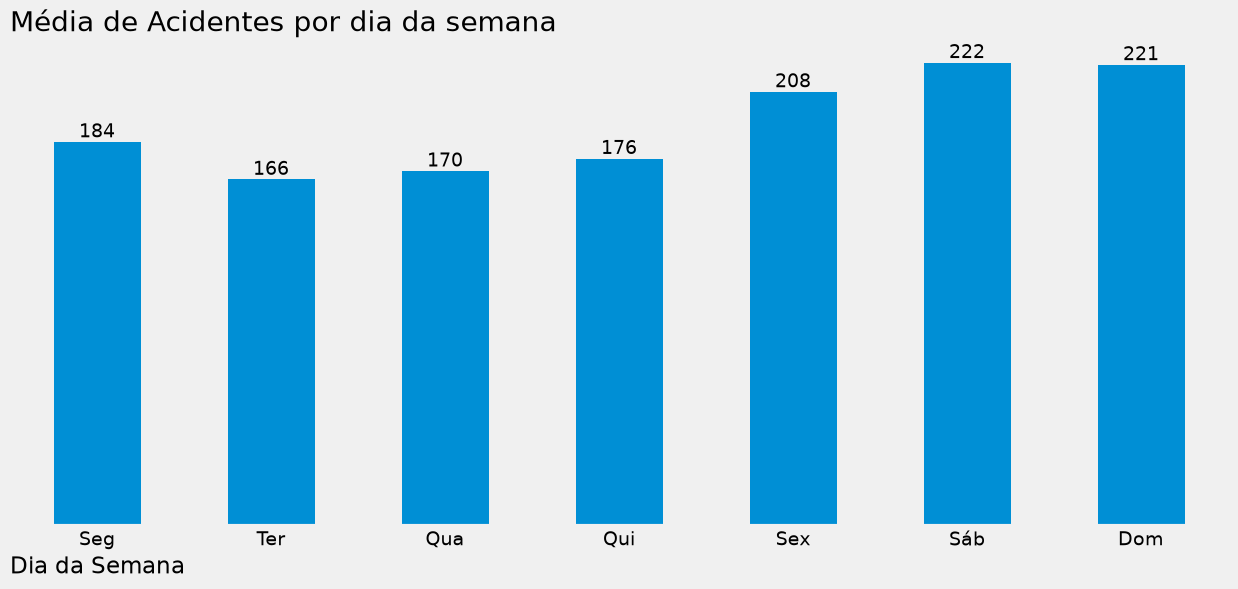

In [42]:
data = df.groupby(["data_inversa", "dia_semana"]).size().groupby("dia_semana").mean().round()

data = data.rename(index=dias)

plotar_grafico( data,"bar", "Média de Acidentes por dia da semana", "Dia da Semana", "Média")

> Como já é esperado, os dias com maior volume são aos finais de semana sex -> dom.
>
> Mas o dia afeta a classificação?

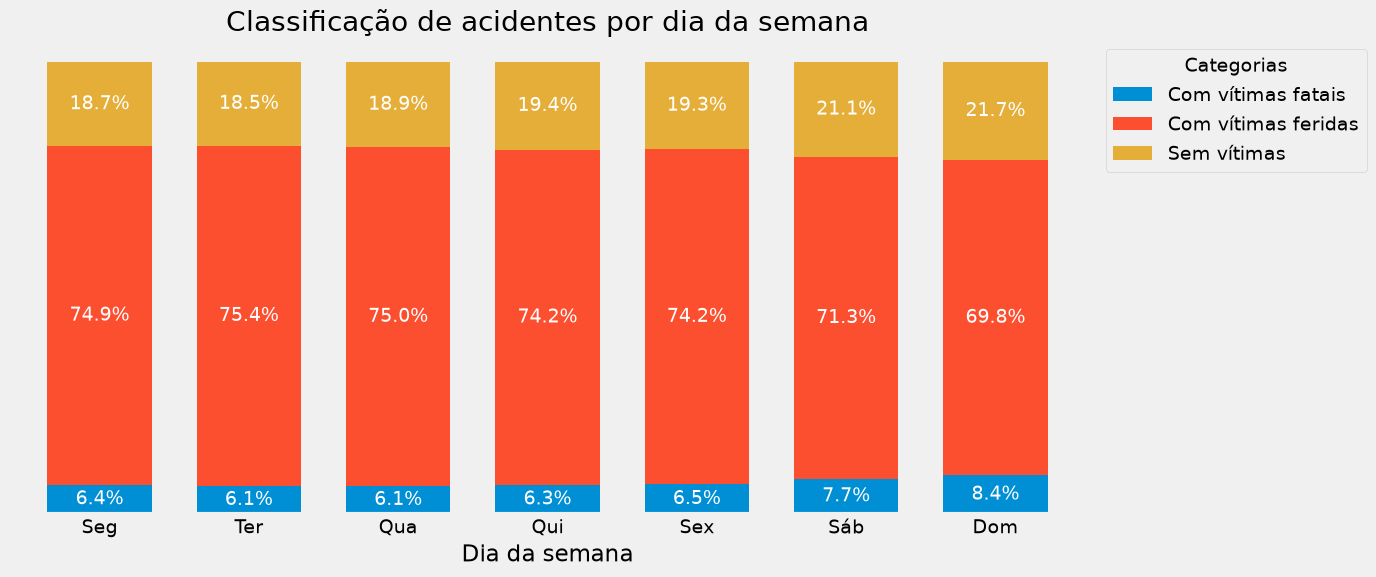

In [44]:
data = (
    df.groupby(["data_inversa", "dia_semana", "classificacao_acidente"])
    .size()
    .groupby(["dia_semana", "classificacao_acidente"])
    .mean()
    .unstack()
)

data = data.rename(index=dias)

data = data.div(data.sum(axis=1), axis=0) * 100


barras_empilhadas(
    data,
    "bar",
    "Classificação de acidentes por dia da semana",
    "Dia da semana",
    "Média",
)


> Sim existe uma diferença nas gravidades, aos sábados e domingos a gravidade fatal aumenta, mas também aumentam os acidentes sem vítimas. 

### Acidentes por faixa horária

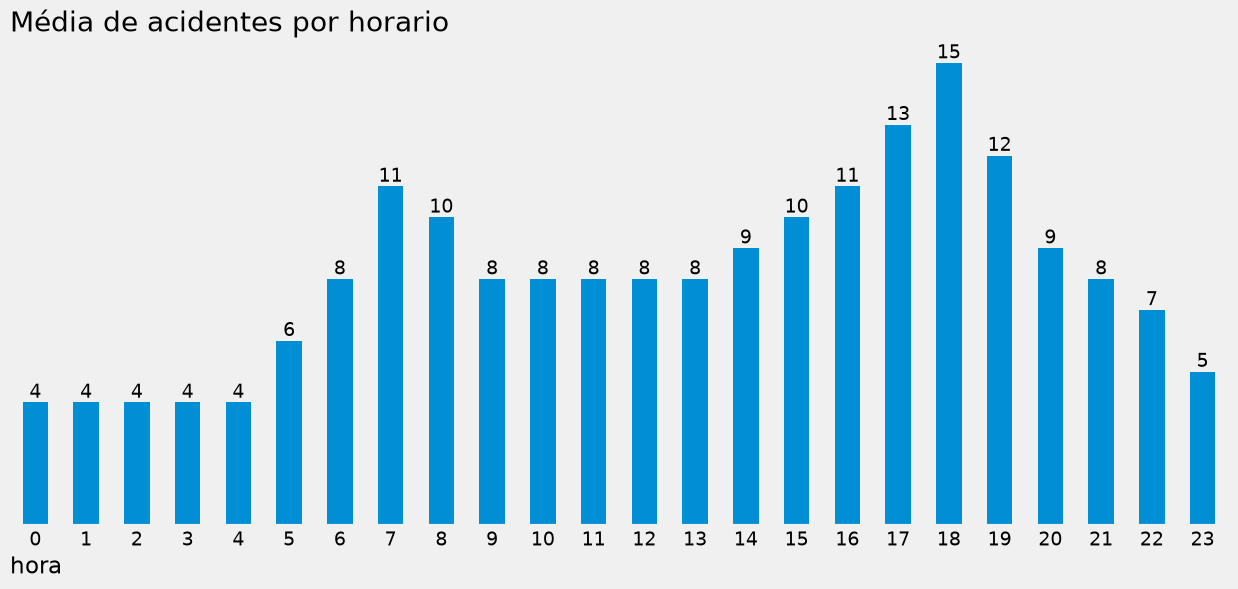

In [51]:
data = df.groupby(["data_inversa", "hora"]).size().groupby("hora").mean().round()

plotar_grafico(data, "bar", "Média de acidentes por horario", "hora", "Média")


> Temos dois picos distintos nas médias de ocorrências, um pela manhã entre 7h e 8h e outro no final do dia as 18h, conhecidente com os horários de pico de maior movimento das pessoas indo ao trabalho e retornando para casa.

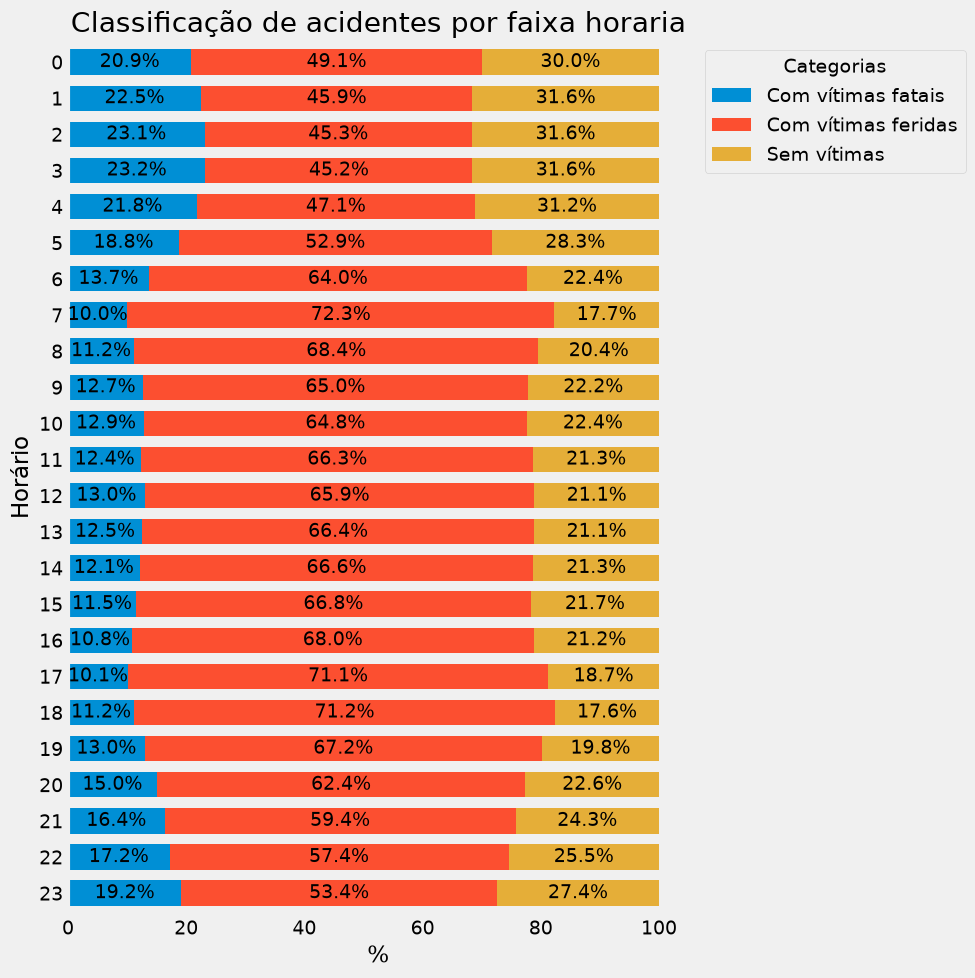

In [72]:
data = (
    df.groupby(["data_inversa", "hora", "classificacao_acidente"])
    .size()
    .groupby(["hora", "classificacao_acidente"])
    .mean()
    .unstack()
)

data = (data.div(data.sum(axis=1), axis=0) * 100).sort_index(ascending=False)


barras_empilhadas(
    data,
    "barh",
    "Classificação de acidentes por faixa horaria",
    "%",
    "Horário",
    figsize=(10, 10)
)


> Embora as noites e madrugadas tenham menos acidentes, a proporção de acidentes graves é bem maior do que em outros horários

## Dados de localização  

### UF

In [95]:
data = df.groupby(["uf", "classificacao_acidente"]).size().unstack()

data.div(data.sum(axis=1), axis=0) * 100

classificacao_acidente,Com vítimas fatais,Com vítimas feridas,Sem vítimas
uf,,,
AC,6.92,77.73,15.34
AL,11.43,66.34,22.22
AM,12.35,57.86,29.79
AP,6.62,73.60,19.79
BA,11.42,70.39,18.19
CE,9.89,70.73,19.38
DF,3.98,75.96,20.06
ES,5.20,83.04,11.76
GO,7.21,71.07,21.72
